In [24]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

path = r"C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\dataset_xgboost_ready.csv"
dataset = pd.read_csv(path)
dataset['Tanggal'] = pd.to_datetime(dataset['Tanggal'])

FEATURES = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
            'Rolling_Mean_2', 'Rolling_Mean_4', 'Rolling_Std_4',
            'Bulan', 'Pekan_Ke', 'Rata_Historis_SKU', 'Is_Ramadan']
TARGET = 'Jumlah'

all_weeks = sorted(dataset['Tanggal'].unique())
print(f"Total minggu: {len(all_weeks)}")
print(f"Minggu ke-1 : {all_weeks[0]}")
print(f"Minggu ke-40: {all_weeks[39]}")
print(f"Minggu ke-41: {all_weeks[40]}")

Total minggu: 53
Minggu ke-1 : 2025-04-29 00:00:00
Minggu ke-40: 2026-01-27 00:00:00
Minggu ke-41: 2026-02-03 00:00:00


In [ ]:
# # Skema:
# # week 1-35  = train_inner (untuk Optuna)
# # week 36-40 = validation  (untuk Optuna)
# # week 41-52 = future test  (untuk walk-forward, TIDAK disentuh Optuna)

# train_inner = dataset[dataset['Tanggal'] < all_weeks[35]].copy()
# val         = dataset[(dataset['Tanggal'] >= all_weeks[35]) &
#                       (dataset['Tanggal'] < all_weeks[40])].copy()

# X_inner, y_inner = train_inner[FEATURES], train_inner[TARGET]
# X_val,   y_val   = val[FEATURES],         val[TARGET]

# print(f"Train inner : {train_inner['Tanggal'].nunique()} minggu, {len(train_inner)} baris")
# print(f"Validation  : {val['Tanggal'].nunique()} minggu, {len(val)} baris")
# print(f"Future test : {len(all_weeks) - 40} minggu (untuk walk-forward)")

Train inner : 35 minggu, 6825 baris
Validation  : 5 minggu, 975 baris
Future test : 13 minggu (untuk walk-forward)


In [25]:
# Skema 3-Fold:
# Fold 1: train 1-25,  val 26-30
# Fold 2: train 1-30,  val 31-35
# Fold 3: train 1-35,  val 36-40
# Future test: weeks 41-52 (tidak disentuh Optuna)

folds = []
# Fold 1
t1 = dataset[dataset['Tanggal'] < all_weeks[25]].copy()
v1 = dataset[(dataset['Tanggal'] >= all_weeks[25]) &
             (dataset['Tanggal'] < all_weeks[30])].copy()
folds.append((t1, v1))

# Fold 2
t2 = dataset[dataset['Tanggal'] < all_weeks[30]].copy()
v2 = dataset[(dataset['Tanggal'] >= all_weeks[30]) &
             (dataset['Tanggal'] < all_weeks[35])].copy()
folds.append((t2, v2))

# Fold 3
t3 = dataset[dataset['Tanggal'] < all_weeks[35]].copy()
v3 = dataset[(dataset['Tanggal'] >= all_weeks[35]) &
             (dataset['Tanggal'] < all_weeks[40])].copy()
folds.append((t3, v3))

# Untuk komparasi baseline vs final
X_val, y_val = v3[FEATURES], v3[TARGET]

# Untuk baseline training
X_inner, y_inner = t3[FEATURES], t3[TARGET]

print(f"Fold 1: train {t1['Tanggal'].nunique()} minggu, val {v1['Tanggal'].nunique()} minggu")
print(f"Fold 2: train {t2['Tanggal'].nunique()} minggu, val {v2['Tanggal'].nunique()} minggu")
print(f"Fold 3: train {t3['Tanggal'].nunique()} minggu, val {v3['Tanggal'].nunique()} minggu")
print(f"Future test: {len(all_weeks) - 40} minggu (untuk walk-forward)")

Fold 1: train 25 minggu, val 5 minggu
Fold 2: train 30 minggu, val 5 minggu
Fold 3: train 35 minggu, val 5 minggu
Future test: 13 minggu (untuk walk-forward)


In [26]:
baseline = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
baseline.fit(X_inner, y_inner, verbose=False)

pred_b = baseline.predict(X_val)
rmse_b = np.sqrt(mean_squared_error(y_val, pred_b))
mae_b  = mean_absolute_error(y_val, pred_b)
r2_b = r2_score(y_val, pred_b)

print("=== BASELINE MODEL (evaluasi di validation set) ===")
print(f"RMSE : {rmse_b:.4f}")
print(f"MAE  : {mae_b:.4f}")
print(f"R2   : {r2_b:.4f}")

=== BASELINE MODEL (evaluasi di validation set) ===
RMSE : 16.0475
MAE  : 7.6944
R2   : -0.3165


In [37]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1, 100, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42
    }
    
    total_rmse = 0
    penalty = 0
    
    for i in range(12):
        test_week  = all_weeks[40 + i]
        train_data = dataset[dataset['Tanggal'] < test_week]
        test_data  = dataset[dataset['Tanggal'] == test_week]
        
        model = xgb.XGBRegressor(**params)
        model.fit(train_data[FEATURES], train_data[TARGET], verbose=False)
        pred = model.predict(test_data[FEATURES])
        
        rmse_xgb = np.sqrt(mean_squared_error(test_data[TARGET], pred))
        rmse_ma4 = np.sqrt(mean_squared_error(test_data[TARGET], test_data['Rolling_Mean_4']))
        
        total_rmse += rmse_xgb
        
        if rmse_xgb >= rmse_ma4:
            penalty += (rmse_xgb - rmse_ma4) * 1000
    
    return float(total_rmse + penalty)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest params: {study.best_params}")
print(f"Best objective: {study.best_value:.4f}")

Best trial: 32. Best value: 126.121: 100%|██████████| 50/50 [10:26<00:00, 12.54s/it]


Best params: {'n_estimators': 434, 'max_depth': 3, 'learning_rate': 0.011612496526152835, 'subsample': 0.6772001067528216, 'colsample_bytree': 0.6367519068629329, 'reg_lambda': 67.88296743291235, 'reg_alpha': 0.0019859558935188173, 'min_child_weight': 6}
Best objective: 126.1212


In [38]:
# Setelah hyperparameter dikunci, latih ulang dengan 40 minggu penuh
train_full = dataset[dataset['Tanggal'] < all_weeks[40]].copy()
X_full, y_full = train_full[FEATURES], train_full[TARGET]

best_params = study.best_params
best_params['random_state'] = 42

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_full, y_full, verbose=False)

# Evaluasi di validation set untuk komparasi dengan baseline
pred_f = final_model.predict(X_val)
rmse_f = np.sqrt(mean_squared_error(y_val, pred_f))
mae_f  = mean_absolute_error(y_val, pred_f)
r2_f  = r2_score(y_val, pred_f)

print("=== BASELINE vs FINAL (di validation set) ===")
print(f"{'Metrik':<8} {'Baseline':>10} {'Final':>10}")
print(f"{'RMSE':<8} {rmse_b:>10.4f} {rmse_f:>10.4f}")
print(f"{'MAE':<8} {mae_b:>10.4f} {mae_f:>10.4f}")
print(f"{'R2':<8} {r2_b:>10.4f} {r2_f:>10.4f}")

joblib.dump(final_model, r'C:\Users\Arifi\Desktop\FORECASTING OBAT\models\xgboost_best_model.joblib')
pd.DataFrame([best_params]).to_csv(r'C:\Users\Arifi\Desktop\FORECASTING OBAT\data\final\best_params.csv', index=False)
print("\nModel tersimpan: xgboost_best_model.joblib")

=== BASELINE vs FINAL (di validation set) ===
Metrik     Baseline      Final
RMSE        16.0475    10.9070
MAE          7.6944     5.4889
R2          -0.3165     0.3918

Model tersimpan: xgboost_best_model.joblib


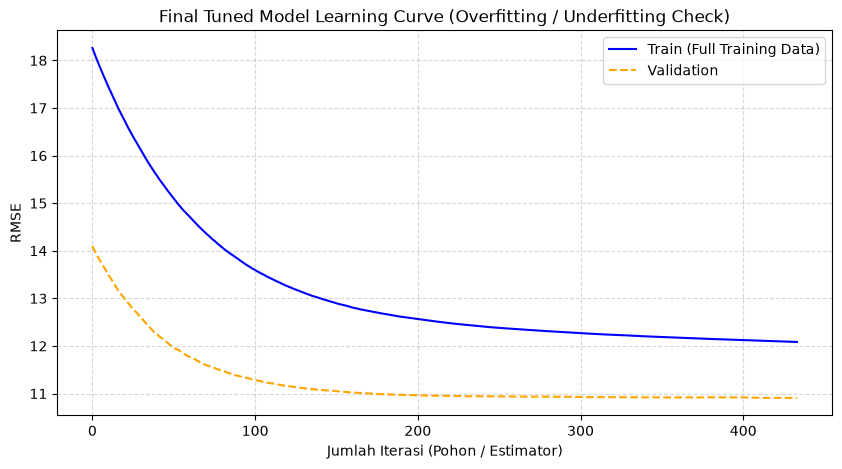

In [39]:
import matplotlib.pyplot as plt

# Salin best_params hasil tuning Optuna
params_lc = best_params.copy()
params_lc['random_state'] = 42

# Buat instance model baru khusus untuk tracking learning curve
eval_final_model = xgb.XGBRegressor(**params_lc)

# Latih model menggunakan data full training dan validation set
eval_final_model.fit(
    X_full, y_full,
    eval_set=[(X_full, y_full), (X_val, y_val)],
    verbose=False
)

# Ambil riwayat evaluasi RMSE
results = eval_final_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Visualisasikan Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['rmse'], color='blue', label='Train (Full Training Data)')
plt.plot(x_axis, results['validation_1']['rmse'], color='orange', linestyle='--', label='Validation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Jumlah Iterasi (Pohon / Estimator)')
plt.ylabel('RMSE')
plt.title('Final Tuned Model Learning Curve (Overfitting / Underfitting Check)')
plt.legend()
plt.show()


            Fitur  Importance
Rata_Historis_SKU    0.399256
   Rolling_Mean_4    0.270038
   Rolling_Mean_2    0.092002
            Lag_1    0.065968
    Rolling_Std_4    0.062267
         Pekan_Ke    0.031853
            Bulan    0.030093
            Lag_4    0.017955
            Lag_2    0.017474
            Lag_3    0.013095
       Is_Ramadan    0.000000


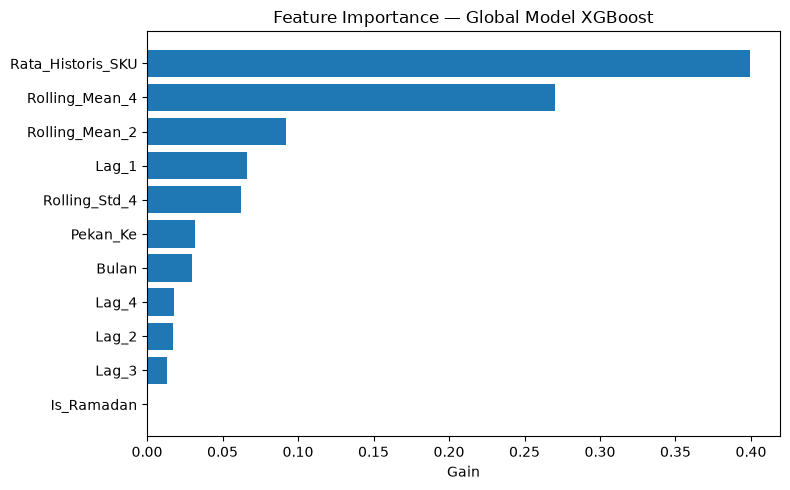

In [40]:
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    'Fitur': FEATURES,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(fi.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(fi['Fitur'][::-1], fi['Importance'][::-1])
plt.title('Feature Importance — Global Model XGBoost')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()